In [104]:
#pip install stop-words

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string
import nltk 
from nltk import ngrams
from nltk.corpus import stopwords 
from nltk.tokenize import word_tokenize
from nltk.tokenize import sent_tokenize
from nltk import FreqDist
from nltk.stem import WordNetLemmatizer,SnowballStemmer
nltk.download('punkt')
nltk.download('stopwords')
#from stop_words import get_stop_words
import json
import os

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Bombino\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Bombino\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [106]:
base_dir = "."
ids_file = os.path.join(base_dir, "os-ccby-40k-ids.csv")
json_dir = os.path.join(base_dir, "json")
output_csv = os.path.join(base_dir, "articles.csv")

# Read the IDs from the CSV file (assuming no header row in the CSV)
print(f"Reading IDs from {ids_file}...")
ids_df = pd.read_csv(ids_file, header=None, names=["doc_id"])
ids_list = ids_df["doc_id"].tolist()

articles = []

print(f"Processing {len(ids_list)} articles...")
for doc_id in ids_list:
    json_path = os.path.join(json_dir, f"{doc_id}.json")
    
    if os.path.exists(json_path):
        with open(json_path, 'r', encoding='utf-8') as f:
            try:
                article_data = json.load(f)
                
                record = {"doc_id": doc_id}
                for key, value in article_data.items():
                    if key == "metadata" and isinstance(value, dict):
                        # Flatten metadata into separate columns
                        for meta_k, meta_v in value.items():
                            if isinstance(meta_v, list):
                                # Handle lists of dicts (like authors) or simple lists (like keywords)
                                if len(meta_v) > 0 and isinstance(meta_v[0], dict) and "last" in meta_v[0]:
                                    record[meta_k] = ", ".join([f"{a.get('first', '')} {a.get('last', '')}".strip() for a in meta_v])
                                else:
                                    record[meta_k] = ", ".join([str(i) for i in meta_v])
                            else:
                                record[meta_k] = meta_v
                    elif key in ["author_highlights", "body_text"] and isinstance(value, list):
                        # Extract only the raw text from the "sentence" attributes
                        record[key] = " ".join([item.get("sentence", "") for item in value if isinstance(item, dict) and "sentence" in item])
                    elif key == "bib_entries" and isinstance(value, dict):
                        # Extract titles and years from bibliographies
                        bibs = [v.get("title", "") + (f" ({v.get('pub_year')})" if v.get("pub_year") else "") for k, v in value.items() if isinstance(v, dict) and v.get("title")]
                        record[key] = " | ".join(bibs)
                    elif isinstance(value, (dict, list)):
                        # Fallback for any other unhandled complex types
                        record[key] = json.dumps(value, ensure_ascii=False)
                    else:
                        record[key] = value
                        
                articles.append(record)
            except json.JSONDecodeError:
                print(f"Warning: Could not decode JSON for file {json_path}")

# Create a DataFrame and save it to CSV
output_df = pd.DataFrame(articles)
output_df.to_csv(output_csv, index=False, encoding='utf-8')
print(f"Success! Dataset created at {output_csv} with {len(output_df)} records.")


Reading IDs from .\os-ccby-40k-ids.csv...
Processing 40001 articles...
Success! Dataset created at .\articles.csv with 40001 records.


In [107]:
#import and visualize dataset
df = pd.read_csv("articles.csv", skipinitialspace=True)
df.head(1)

,doc_id,abstract,bib_entries,body_text,docId,asjc,authors,doi,firstpage,issn,lastpage,openaccess,pub_year,subjareas,title,keywords,author_highlights
0,S2352340916308101,The data presented here were originally collec...,The Analysis of Spatial Association by Use of ...,"However, a key limitation of this approach usi...",S2352340916308101,1000,"Juan Miguel Rodriguez Lopez, Katharina Heider,...",10.1016/j.dib.2016.12.049,5,23523409,11,Full,2017,MULT,Human and remote sensing data to investigate t...,NaN,NaN


In [108]:
df.shape

(40001, 17)

In [109]:
(df["doc_id"] == df["docId"]).all()

np.True_

In [110]:
df.drop(columns=["docId"], inplace=True)

In [111]:
pd.set_option('display.max_colwidth', None)

In [112]:
df.head(1)

doc_id  \
0  S2352340916308101   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            abstract  \
0  The data presented here were originally collected for the article “Frontiers of Urbanization: Identifying and Explaining Urbanization Hot Spots in the South of Mexico City Using Human and Remote Sensing” (Rodriguez et al. 2017) [4]. They were divided into three databases (remote sensing, human sensing, and census information), using a multi-method approach with the goal of analyzing the impact of urbanization on protected areas in southern Mexico City. The remote sensing database was prepared as a result of a semi-automatic classification, dividing the land cover data into urban and non-urban classes. The second data set details an alternative view of the phenomena of urbanization by concentrating on illegal settlements in the conservation zone. It was based on voluntary complaints about environmental and land use offences filed at the Procuraduria Ambiental y del Ordenamiento Territorial del Distrito Federal (PAOT), which is a governmental entity responsible for reviewing and processing grievances on five basic topics: illegal land use, deterioration of green areas, waste, noise/vibrations, and animals. Anyone can file a PAOT complaint by phone, electronically, or in person. The complaint ends with a resolution, act of conciliation, or recommendation for action by other actors, such as the police or health office. The third data about unemployment was extracted from Mexico׳s National Census 2010 database available via public access.   

                                                                                                                                                                                                                                                                                                             bib_entries  \
0  The Analysis of Spatial Association by Use of Distance Statistics (1992) | Local Spatial Autocorrelation Statistics: Distributional Issues and an Application (1995) | Frontiers of urbanization: Identifying and explaining urbanization hot spots in the south of Mexico City using human and remote sensing (2017)   

                                                                                                                                                                                                                                                                                                                                                                                                                   

In [113]:
pd.reset_option('display.max_colwidth')

In [114]:
df["openaccess"].unique()
df["openaccess"].value_counts()

openaccess
Full          39954
Repository       34
Name: count, dtype: int64

In [115]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40001 entries, 0 to 40000
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   doc_id             40001 non-null  str  
 1   abstract           39525 non-null  str  
 2   bib_entries        38830 non-null  str  
 3   body_text          40001 non-null  str  
 4   asjc               40001 non-null  str  
 5   authors            39994 non-null  str  
 6   doi                39999 non-null  str  
 7   firstpage          35366 non-null  str  
 8   issn               40001 non-null  str  
 9   lastpage           35274 non-null  str  
 10  openaccess         39988 non-null  str  
 11  pub_year           40001 non-null  int64
 12  subjareas          40001 non-null  str  
 13  title              40001 non-null  str  
 14  keywords           35505 non-null  str  
 15  author_highlights  24850 non-null  str  
dtypes: int64(1), str(15)
memory usage: 1.4 GB


In [116]:
df[df["openaccess"] == "Repository"].head()

,doc_id,abstract,bib_entries,body_text,asjc,authors,doi,firstpage,issn,lastpage,openaccess,pub_year,subjareas,title,keywords,author_highlights
4791,S0014579314006176,Sister chromatid cohesion involves entrapment ...,iMOSFLM: A new graphical interface for diffrac...,A more sensitive assay is to measure the abili...,"1303, 1304, 1307, 1311, 1312, 1315","Maurici B. Roig, Jan Löwe, Kok Lung Chan, Fréd...",10.1016/j.febslet.2014.08.015,3692,00145793,3702,Repository,2014,BIOC,Structure and function of cohesin's Scc3/SA re...,"Cohesin complex, Eco1 acetylation, Maintenance...","Crystal structure of cohesin subunit Scc3/SA, ..."
4823,S0014579314008199,Golgi Arf1-guanine nucleotide exchange factors...,The small G proteins of the Arf family and the...,Fungal life is crucially dependent on exocytos...,"1303, 1304, 1307, 1311, 1312, 1315","Herbert N. Arst, Miguel Hernandez-Gonzalez, Mi...",10.1016/j.febslet.2014.11.014,4799,00145793,4806,Repository,2014,BIOC,GBF/Gea mutant with a single substitution sust...,"BIG/Sec7-subfamily, Fungal secretion, GBF/Gea-...",A. nidulans has a GBF/Gea and a BIG/Sec7 subfa...
4898,S001457931400578X,Understanding how single nucleotide polymorphi...,CARD15 mutations in Blau syndrome (2001) | Gen...,Chemical reagents were obtained from Sigma–Ald...,"1303, 1304, 1307, 1311, 1312, 1315","Rhiannon Parkhouse, Joseph P. Boyle, Tom P. Monie",10.1016/j.febslet.2014.07.029,3382,00145793,3389,Repository,2014,BIOC,Blau syndrome polymorphisms in NOD2 identify n...,"Blau syndrome, Innate immunity, NACHT, Nucleot...",NOD2 SNPs that cause Blau syndrome cluster in ...
4950,S0014579314009065,Recent studies have indicated that non-coding ...,Origin and physiological roles of inflammation...,"Cells were subsequently incubated for 6 h, dil...","1303, 1304, 1307, 1311, 1312, 1315","James A. Heward, Benoit T. Roux, Mark A. Lindsay",10.1016/j.febslet.2014.12.026,396,00145793,406,Repository,2015,BIOC,Divergent signalling pathways regulate lipopol...,"ERK and p38, Enhancer RNA, Lipopolysaccharide,...",eRNAs are expressed from enhancers and have be...
5242,S0014579314004256,PEX5 acts as a cycling receptor for import of ...,Getting a camel through the eye of a needle: t...,Peroxisomal matrix proteins are post-translati...,"1303, 1304, 1307, 1311, 1312, 1315","Thomas Lanyon-Hogg, Jacob Hooper, Sarah Gunn, ...",10.1016/j.febslet.2014.05.038,2223,00145793,2229,Repository,2014,BIOC,PEX14 binding to Arabidopsis PEX5 has differen...,"Arabidopsis thaliana, Cargo unloading, PEX14, ...",The interaction between Arabidopsis PEX5 and P...


In [117]:
df.drop(columns=["doi", "firstpage", "issn", "lastpage", "author_highlights", "keywords", "bib_entries"], inplace=True)

In [118]:
df.dropna(inplace=True)

In [119]:
df.isnull().sum()

doc_id        0
abstract      0
body_text     0
asjc          0
authors       0
openaccess    0
pub_year      0
subjareas     0
title         0
dtype: int64

In [120]:
# keep=False mostra sia l'originale che tutte le copie presenti
duplicati_completi = df[df.duplicated(subset=['body_text'], keep=False)]
 
# Ordina i risultati per vedere i blocchi uguali uno sotto l'altro
duplicati_completi = duplicati_completi.sort_values(by=['body_text'])
print(duplicati_completi)

                  doc_id                                           abstract  \
1046   S1090023317301910  The recent outbreak of infection with Zika vir...   
1242   S1090023314005309  Beagles are commonly used in vaccine trials as...   
10048  S2590155919300010  Sorbitol can be produced photosynthetically in...   
16416  S0025326X19308781  Marine debris, particularly plastic and abando...   

                                               body_text              asjc  \
1046   None of the authors of this paper has a financ...        1103, 3400   
1242   None of the authors of this paper has a financ...        1103, 3400   
10048  The authors declare that they have no known co...  1305, 1502, 2402   
16416  The authors declare that they have no known co...  1104, 1910, 2310   

                                                 authors openaccess  pub_year  \
1046   Jamie Royle, Claire L. Donald, Andres Merits, ...       Full      2017   
1242   Francesca Soutter, Lorna J. Kennedy, William

In [121]:
# Calculate word counts for the text column (e.g., 'body_text')
word_counts = df['body_text'].str.split().str.len()

# Create a boolean mask of rows that exceed 40,000 words
over_limit_mask = word_counts > 40000

# Reassign the DataFrame to keep only the rows that are NOT (~) over the limit
df = df[~over_limit_mask]

# Print the number of dropped rows to verify
dropped_count = over_limit_mask.sum()
print(f"Dropped {dropped_count} rows containing over 40,000 words.")

Dropped 3 rows containing over 40,000 words.


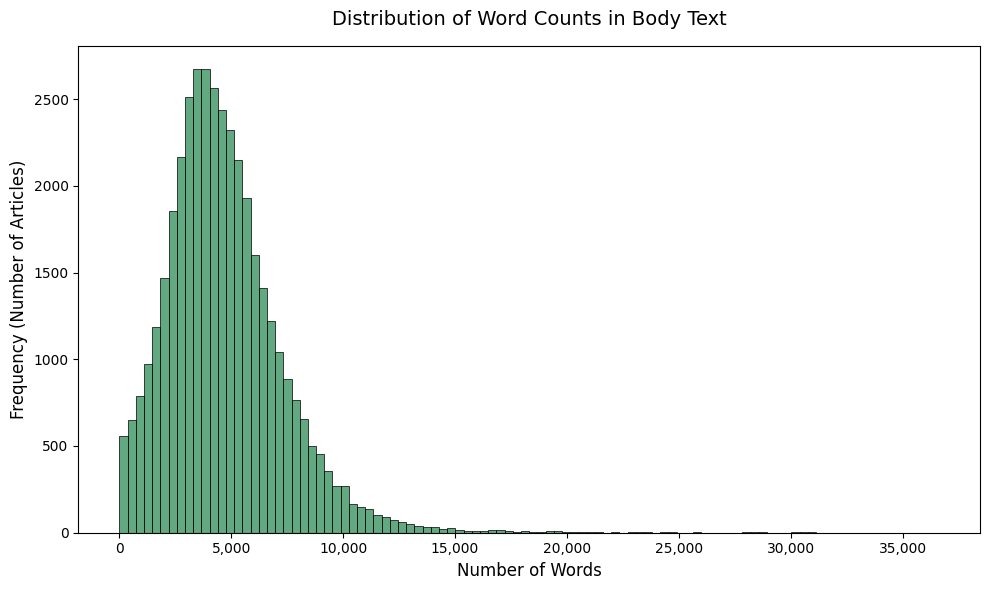

In [122]:
word_counts = df['body_text'].dropna().str.split().str.len()

plt.figure(figsize=(10, 6))

sns.histplot(x=word_counts, bins=100, color='seagreen')

plt.title('Distribution of Word Counts in Body Text', fontsize=14, pad=15)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency (Number of Articles)', fontsize=12)

plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()


In [123]:
df['word_count'] = df['body_text'].fillna('').str.split().str.len()

df_sorted = df.sort_values(by='word_count', ascending=True)

In [124]:
df_sorted[['doc_id', 'word_count', 'body_text']].head(100)

,doc_id,word_count,body_text
30800,S2352771416300192,4,Conflicts of interest: none.
20350,S2590150819300389,6,There are no conflicts of interest.
27810,S1672022918304327,6,The authors declare no competing interests.
29610,S221454001500002X,6,The authors declare no completing interests.
10191,S0168165617317443,7,The authors declare no conflicts of interest.
...,...,...,...
27414,S0022247X19308339,54,A. Atzmon in [1] published a construction of a...
38083,S0370269317309036,55,We hope that the techniques developed here wil...
27589,S1063520318301623,56,"We, however, do not pursue this issue here and..."
4684,S0047637416300069,56,"CF, SW and BP performed mouse work. We certify..."


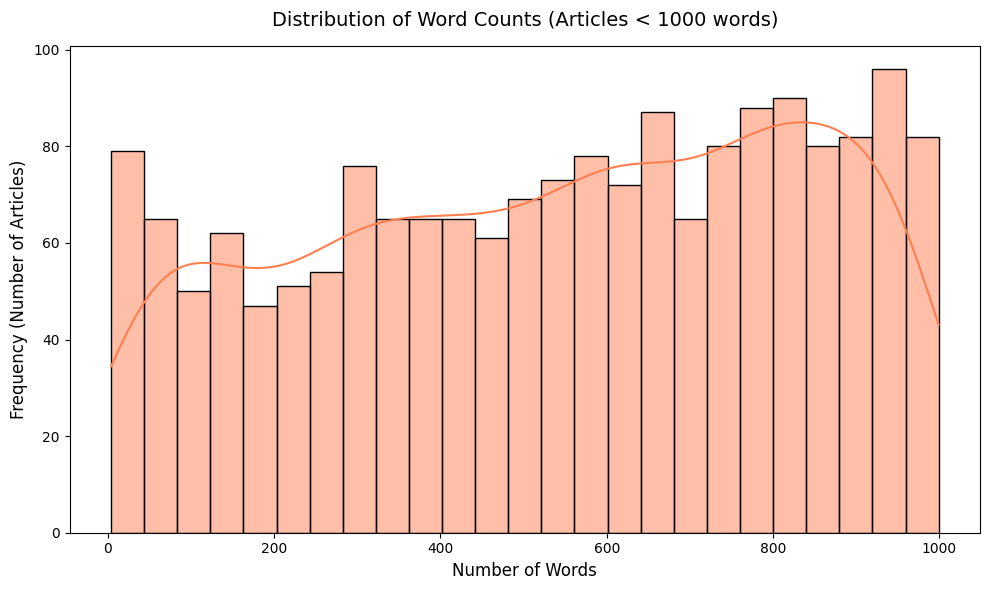

In [125]:
word_counts = df['body_text'].fillna('').str.split().str.len()

short_articles = word_counts[word_counts < 1000]

plt.figure(figsize=(10, 6))

sns.histplot(short_articles, bins=25, kde=True, color='coral')

plt.title('Distribution of Word Counts (Articles < 1000 words)', fontsize=14, pad=15)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency (Number of Articles)', fontsize=12)

plt.tight_layout()
plt.show()


In [126]:
MIN_WORDS_THRESHOLD = 500

word_counts = df['body_text'].fillna('').str.split().str.len()

df = df[word_counts >= MIN_WORDS_THRESHOLD]

print(f"Remaining dataset size: {len(df)} rows.")


Remaining dataset size: 38731 rows.


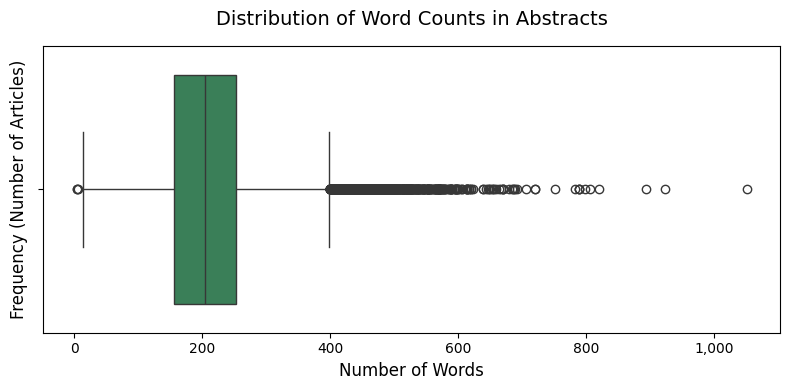

In [127]:
word_counts_abstract = df['abstract'].dropna().str.split().str.len()

plt.figure(figsize=(8, 4))

sns.boxplot(x=word_counts_abstract, color='seagreen')

plt.title('Distribution of Word Counts in Abstracts', fontsize=14, pad=15)
plt.xlabel('Number of Words', fontsize=12)
plt.ylabel('Frequency (Number of Articles)', fontsize=12)

plt.gca().xaxis.set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

In [128]:
df['word_count_abstract'] = df['abstract'].fillna('').str.split().str.len()

df_sorted = df.sort_values(by='word_count_abstract', ascending=True)
df_sorted[['doc_id', 'word_count_abstract', 'abstract']].head(20)

,doc_id,word_count_abstract,abstract
30,S2589004219304365,4,Genetics; Molecular Genetics; Biophysics
257,S2589004219304717,5,Organic Chemistry; Chemical Compound; Biochemi...
216,S2589004219301956,6,Developmental Genetics; Developmental Biology;...
69,S240584401936308X,13,Biotechnology; Pharmaceutical Science; Cryo-TE...
19,S2405844019362917,13,Agricultural science; Biochemistry; Plant biol...
272,S2405844019366575,14,Biochemistry; Toxicology; Hematological system...
26,S2405844019365715,14,"Analytical chemistry; Inorganic chemistry, Dec..."
23060,S0269749118353843,17,Crude oil derived monoaromatic hydrocarbons ac...
36168,S1359644619304684,17,It is high time to integrate computational mod...
27623,S2468042716300367,17,We give a brief outline of some of the importa...


In [129]:
df["word_count_abstract"] = df["abstract"].fillna("").str.split().str.len()
df.loc[df["word_count_abstract"] < 15, "abstract"] = np.nan

In [130]:
df.describe()

,pub_year,word_count,word_count_abstract
count,38731.000000,38731.000000,38731.000000
mean,2017.220185,4794.975110,212.796210
std,1.715908,2605.862465,78.414507
min,2014.000000,500.000000,4.000000
25%,2016.000000,3057.500000,156.000000
50%,2017.000000,4410.000000,204.000000
75%,2019.000000,6061.000000,253.000000
max,2020.000000,36630.000000,1050.000000


## ARTICLES TEXT CLEANING

In [134]:
import string

custom_stopwords = {
    # lettere singole
    *string.ascii_lowercase, 
    # abbreviazioni
    'et', 'al', 'ie', 'eg', 'vs', 'cf', 'nb', 'viz', 'approx',
    'dept', 'univ', 'prof', 'dr', 'mr', 'ms',
    # unità di misura
    'ml', 'mg', 'kg', 'km', 'mm', 'cm', 'nm', 'hz', 'khz', 'mhz',
    'kb', 'mb', 'gb', 'min', 'sec', 'hrs',
    # artefatti pdf
    'pp', 'vol', 'doi', 'isbn', 'issn', 'http', 'www', 'org', 'com',
    'copyright', 'rights', 'reserved', 'license',
    # parole generiche articoli
    'paper', 'article', 'section', 'chapter', 'introduction', 'conclusion',
    'abstract', 'appendix', 'supplementary', 'bibliography', 'references',
    # figure e tabelle
    'fig', 'figure', 'figures', 'table', 'tables',
}

new_stopwords = set(stopwords.words('english')) | custom_stopwords

In [135]:
#This function was used to transform words from contracted form to extended form
def fullwords(text):
    text = re.sub(r"can\'t", " can not", text)
    text = re.sub(r"won\'t", " will not", text)
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would", text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    text = re.sub(r"wasn\'t", " was not", text)
    text = re.sub(r"i\'ve", " i have", text)
    text = re.sub(r"don\'t", " do not", text)
    text = re.sub(r"didn\'t", " did not", text)
    text = re.sub(r"aint", " am not", text)
    text = re.sub(r"you\'re", " you are", text)
    text = re.sub(r"isn\'t", " is not", text)   
    return text

In [136]:
#Function to  punctuation, links, stopwords, mentions and \r\n new line characters
def strip_all_entities(text): 
    text = re.sub(r'\[.*?\]|\([^)]*\d{4}[^)]*\)', '', text)
    text = re.sub(r'http\S+', '', text) #remove links
    text = re.sub(r'https?://\S+', '', text)
    text = re.sub(r'www\.\S+', '', text)
    text = text.replace('/', ' ') #remove "/"
    text = text.replace('\r', '').replace('\n', ' ').lower() #remove \n and \r and lowercase
    text = re.sub(r'[^\x00-\x7f]',r'', text) #remove non utf8/ascii characters such as '\x9a\x91\x97\x9a\x97'
    text = re.sub(r'[0-9\.]+', '', text) #remove numbers
    banned_list= string.punctuation #remove punctuation

    table = str.maketrans('', '', banned_list)
    text = text.translate(table)
    
    text = [word for word in text.split() if word not in new_stopwords]
    text = ' '.join(text)
    return text

In [137]:
#funzione apply prende una funzione come input e applica questa funzione a un intero DataFrame.
#Se si lavora con dati tabulari, bisogna specificare un asse su cui vuoi che la tua funzione agisca (0 per le colonne e 1 per le righe).

#in a new temporary column "body_clean1" we save the result of the fuction "apply" on the body_text column in our dataset
#function apply takes a function as input (in this case the function "strip_all_entities") and apply it across the entire column of the dataset
df['body_clean1'] = df['body_text'].apply(lambda x: strip_all_entities(x))
#in a new (definitive) column "body_clean" we save the result of the fuction "apply" (with "fullwords" function as input) 
#"body_clean" is the new column of the dataset where the text of each article has been cleaned up
df['body_clean'] = df['body_clean1'].apply(lambda x: fullwords(x))

#eliminate duplicates, if any
df.drop_duplicates("body_clean", inplace=True)

In [138]:
#eliminate the temporary column "body_clean1"
df= df.drop(["body_clean1"], axis=1)
#to test if the drop function worked well 
df.columns

Index(['doc_id', 'abstract', 'body_text', 'asjc', 'authors', 'openaccess',
       'pub_year', 'subjareas', 'title', 'word_count', 'word_count_abstract',
       'body_clean'],
      dtype='str')

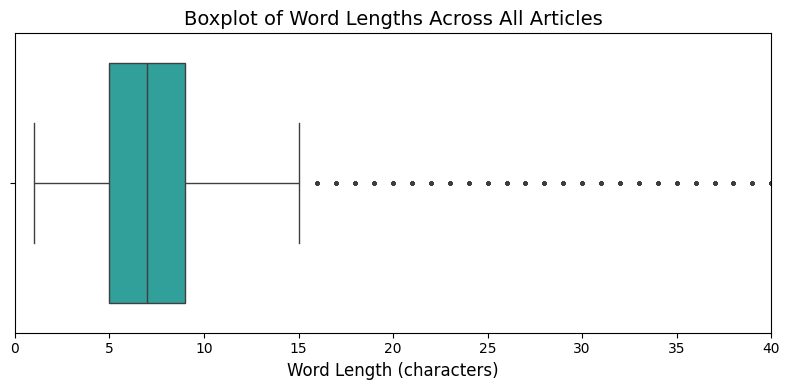

In [139]:
from collections import Counter

word_length_counts = Counter()

for text in df['body_clean'].dropna():
    word_length_counts.update(len(word) for word in text.split())

lengths = list(word_length_counts.keys())
counts = list(word_length_counts.values())
expanded_lengths = np.repeat(lengths, counts)
plt.figure(figsize=(8, 4))
sns.boxplot(x=expanded_lengths, color='lightseagreen', fliersize=2)
plt.title('Boxplot of Word Lengths Across All Articles', fontsize=14)
plt.xlabel('Word Length (characters)', fontsize=12)

plt.xlim(0, 40)

plt.tight_layout()
plt.show()

In [140]:
LENGTH_THRESHOLD = 15

from collections import Counter

unique_long_words = set()
total_length_counts = Counter()  # conta ogni occorrenza, non solo uniche

for text in df['body_clean'].dropna():
    for word in text.split():
        if len(word) > LENGTH_THRESHOLD:
            unique_long_words.add(word)
            total_length_counts[len(word)] += 1  # conta ogni volta che appare

unique_length_counts = Counter(len(word) for word in unique_long_words)

print(f"Parole uniche con più di {LENGTH_THRESHOLD} caratteri: {len(unique_long_words)}")
print(f"Occorrenze totali: {sum(total_length_counts.values())}")
print()
print(f"{'Chars':>6} | {'Uniche':>8} | {'Totali':>8}")
print("-" * 30)
for length in sorted(total_length_counts.keys()):
    print(f"{length:>6} | {unique_length_counts[length]:>8} | {total_length_counts[length]:>8}")

Parole uniche con più di 15 caratteri: 113175
Occorrenze totali: 543480

 Chars |   Uniche |   Totali
------------------------------
    16 |    26791 |   207536
    17 |    20598 |   132700
    18 |    15935 |    72356
    19 |    11939 |    40879
    20 |     9931 |    31215
    21 |     6822 |    16898
    22 |     4835 |    12445
    23 |     3489 |     7389
    24 |     2615 |     5375
    25 |     1930 |     3169
    26 |     1383 |     2596
    27 |     1053 |     1722
    28 |      831 |     1527
    29 |      689 |     1238
    30 |      617 |      913
    31 |      434 |      708
    32 |      400 |      631
    33 |      325 |      527
    34 |      272 |      420
    35 |      244 |      360
    36 |      236 |      530
    37 |      185 |      291
    38 |      182 |      302
    39 |      162 |      227
    40 |      142 |      180
    41 |      108 |      125
    42 |      108 |      129
    43 |       77 |      104
    44 |       76 |       97
    45 |       71 |       

In [141]:
# Define what constitutes a "long" word
LENGTH_THRESHOLD = 15

# Define how many examples you want to output
NUM_EXAMPLES = 30

long_words = set()

# Iterate through the text column
for text in df['body_clean'].dropna():
    for word in text.split():
        if len(word) > LENGTH_THRESHOLD:
            long_words.add(word)

# Sort the collected words by length in descending (inverse) order
sorted_long_words = sorted(list(long_words), key=len, reverse=True)

print(f"Top {NUM_EXAMPLES} longest unique words in the dataset:")
print("-" * 50)

# Print the sorted words along with their character count for context
for long_word in sorted_long_words[:NUM_EXAMPLES]:
    print(f"{len(long_word)} chars : {long_word}")


Top 30 longest unique words in the dataset:
--------------------------------------------------
33526 chars : ...
609 chars : mvskgeednmaiikefmrfkvhmegsvnghefeiegegegrpyegtqtaklkvtkggplpfawdilspqfmygskayvkhpadipdylklsfpegfkwervmnfedggvvtvtqdsslqdgefiykvklrgtnfpsdgpvmqkktmgweassermypedgalkgeikqrlklkdgghydaevkttykakkpvqlpgaynvniklditshnedytiveqyeraegrhstggmdelykgggsmvskgeelftgvvpilveldgdvnghkfsvsgegegdatygkltlkficttgklpvpwptlvttltygvqcfsrypdhmkqhdffksampegyvqertiffkddgnyktraevkfegdtlvnrielkgidfkedgnilghkleynynshnvyimadkqkngikvnfkirhniedgsvqladhyqqntpigdgpvllpdnhylstqsalskdpnekrdhmvllefvtaagitlgmdelyksglgsmpsektfkqrrsfeqrvedvrlireqhptkipviierykgekqlpvldktkflvpdhvnmselikiirrrlqlnanqaffllvnghsmvsvstpisevyeserdedgflymvyasqetfgtalav
199 chars : tcgaagttcgcgttctgtcanrbforwardctggtgaccaatggcaagcacgreverseggtacagagaagtcaaccacctpsdforwardctccccctgtgattgtcaacreversectctgttccattcacctgcaacgapdhforwardggagcgagatcccgtcaagareversecacaaacatgggggcatcag
197 chars : agaagtttttagaggtcccagctgagatagctggtggtggc

In [142]:
lost_words = [w for w in long_words if 40 < len(w) <= 70]
print(f"Parole eliminate con soglia 25 ma non 40: {len(lost_words)}")
for w in sorted(lost_words, key=len)[:50]:
    print(f"{len(w)} : {w}")

Parole eliminate con soglia 25 ma non 40: 1032
41 : cyanoabhexahydrocyclopentindolylpropenoic
41 : gammaproteobacterialbetaproteobacteriales
41 : hbenzotriazolylbismethylphenylethylphenol
41 : dioctadecyltetramethylindotricarbocyanine
41 : encoderfactorycreatehlafloatbearrivaltime
41 : hydroxyethyldimethylcyclobutanecarboxylic
41 : reverseatgcctgcaggtcgacgccacagagaagttgttg
41 : tertbutylchlorhbenzotriazolylmethylphenol
41 : bistertbutylylbenzylpiperazinecarboxylate
41 : ndifluorobenzylpiperidinylquinazolinamine
41 : boninitictholeiiticcalcalkalicshoshonitic
41 : butyryloxyphenylmethanepphenylphosphinate
41 : gcagatcaacatccctgaaagtcgcttccatgcctatggtc
41 : cognitivesocioorganizationalinstitutional
41 : ctcgagaattatttttgtaatcaagataaaagcttaggggc
41 : aaaaaaaaaaaaaaaaaaaaittccakgccgccccccgtct
41 : ttaatacgactcactatagggagactgacggctggcctcct
41 : ttcctggtgcagactttactattcaagaaacgaccgggacc
41 : benzylbenzoxazolylthiotriazolodpyrimidine
41 : reverseatgcctgcaggtcgaattgggcagcaaagagatg
41 : diethylh

In [143]:
MAX_TOKEN_LENGTH = 40

df['body_clean'] = df['body_clean'].apply(
    lambda text: ' '.join(word for word in text.split() if len(word) <= MAX_TOKEN_LENGTH)
    if pd.notna(text) else text
)

In [144]:
n_nan_abstract = df["abstract"].isna().sum()

df = df.dropna(subset=["abstract"]).copy()

print(f"Abstract eliminati perché NaN: {n_nan_abstract}")

Abstract eliminati perché NaN: 7


In [145]:
df['abstract_clean1'] = df['abstract'].apply(lambda x: strip_all_entities(x))
df['abstract_clean'] = df['abstract_clean1'].apply(lambda x: fullwords(x))
df= df.drop(["abstract_clean1"], axis=1)

df.drop_duplicates("abstract_clean", inplace=True)

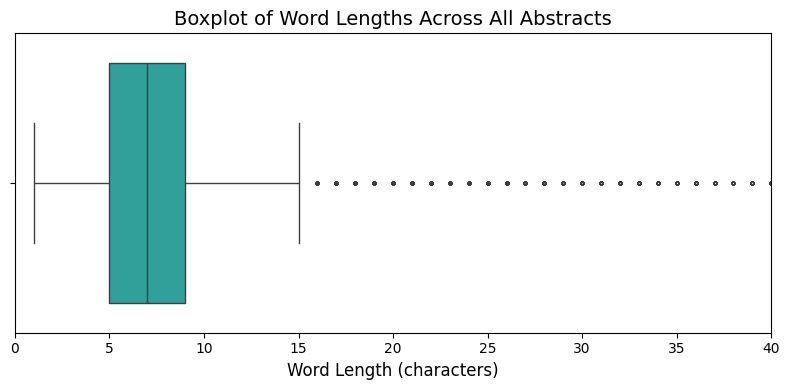

In [146]:
from collections import Counter

word_length_counts = Counter()

for text in df['abstract_clean'].dropna():
    word_length_counts.update(len(word) for word in text.split())

lengths = list(word_length_counts.keys())
counts = list(word_length_counts.values())
expanded_lengths = np.repeat(lengths, counts)
plt.figure(figsize=(8, 4))
sns.boxplot(x=expanded_lengths, color='lightseagreen', fliersize=2)
plt.title('Boxplot of Word Lengths Across All Abstracts', fontsize=14)
plt.xlabel('Word Length (characters)', fontsize=12)

plt.xlim(0, 40)

plt.tight_layout()
plt.show()

In [147]:
LENGTH_THRESHOLD = 15

from collections import Counter

unique_long_words = set()
total_length_counts = Counter()  # conta ogni occorrenza, non solo uniche

for text in df['abstract_clean'].dropna():
    for word in text.split():
        if len(word) > LENGTH_THRESHOLD:
            unique_long_words.add(word)
            total_length_counts[len(word)] += 1  # conta ogni volta che appare

unique_length_counts = Counter(len(word) for word in unique_long_words)

print(f"Parole uniche con più di {LENGTH_THRESHOLD} caratteri: {len(unique_long_words)}")
print(f"Occorrenze totali: {sum(total_length_counts.values())}")
print()
print(f"{'Chars':>6} | {'Uniche':>8} | {'Totali':>8}")
print("-" * 30)
for length in sorted(total_length_counts.keys()):
    print(f"{length:>6} | {unique_length_counts[length]:>8} | {total_length_counts[length]:>8}")

Parole uniche con più di 15 caratteri: 15500
Occorrenze totali: 40691

 Chars |   Uniche |   Totali
------------------------------
    16 |     4271 |    15078
    17 |     3174 |    10199
    18 |     2355 |     5353
    19 |     1603 |     3082
    20 |     1207 |     2561
    21 |      774 |     1265
    22 |      570 |      965
    23 |      389 |      593
    24 |      266 |      423
    25 |      189 |      227
    26 |      146 |      207
    27 |      116 |      136
    28 |       74 |      123
    29 |       61 |      104
    30 |       55 |       69
    31 |       39 |       45
    32 |       44 |       62
    33 |       24 |       28
    34 |       20 |       22
    35 |       20 |       23
    36 |       17 |       30
    37 |        9 |       11
    38 |        6 |        6
    39 |        8 |        8
    40 |        5 |        6
    41 |        5 |        5
    42 |        5 |        8
    43 |        4 |        5
    44 |        5 |        5
    45 |        3 |        3

In [148]:
# Define what constitutes a "long" word
LENGTH_THRESHOLD = 15

# Define how many examples you want to output
NUM_EXAMPLES = 30

long_words = set()

# Iterate through the text column
for text in df['abstract_clean'].dropna():
    for word in text.split():
        if len(word) > LENGTH_THRESHOLD:
            long_words.add(word)

# Sort the collected words by length in descending (inverse) order
sorted_long_words = sorted(list(long_words), key=len, reverse=True)

print(f"Top {NUM_EXAMPLES} longest unique words in the dataset for abstracts:")
print("-" * 50)

# Print the sorted words along with their character count for context
for long_word in sorted_long_words[:NUM_EXAMPLES]:
    print(f"{len(long_word)} chars : {long_word}")


Top 30 longest unique words in the dataset for abstracts:
--------------------------------------------------
89 chars : ntransmethoxyrmethylmorpholinohpyrazolopyrimidinylaminocyclohexylmethylpropanesulfonamide
77 chars : diphtheriatetanusacellularpertussishepatitisbinactivatedpoliovirushaemophilus
73 chars : heptafluorobutanoiloxyhexyloxybiphenylcarboxylansmethyloheptyloxycarbonyl
73 chars : snnacetylllysyllisoleucyllthreonyllalanyldifluorooxoaminopentanoylglycine
72 chars : snnacetyllisoleucyllthreonyllalanylaminodifluorooxoaminopentanoylglycine
72 chars : ntrifluoromethylphenyldihydrohydroxymethoxymethyloxoquinolinecarboxamide
64 chars : sarsasapogeninooglucopyranosyloarabinopyranosylgalactopyranoside
62 chars : nethylnphenylchlorodihydrohydroxymethyloxoquinolinecarboxamide
62 chars : bismethoxyphenylphenylphenylaminotetrahydropyridinecarboxylate
62 chars : triphenylphosphinetetraphenyldiselenoimidodiphosphinatocopperi
61 chars : polydithienyldioctyldodecylpyrrolopyrroledionethienoth

In [149]:
MAX_TOKEN_LENGTH = 40

df['abstract_clean'] = df['abstract_clean'].apply(
    lambda text: ' '.join(word for word in text.split() if len(word) <= MAX_TOKEN_LENGTH)
    if pd.notna(text) else text
)

In [150]:
df.shape

(38711, 13)

In [151]:
df.columns

Index(['doc_id', 'abstract', 'body_text', 'asjc', 'authors', 'openaccess',
       'pub_year', 'subjareas', 'title', 'word_count', 'word_count_abstract',
       'body_clean', 'abstract_clean'],
      dtype='str')

In [152]:
apostrophe_words = set()

for text in df['body_clean'].dropna():
    for word in text.split():
        if "'" in word:
            apostrophe_words.add(word.lower())

print(f"Token con apostrofo trovati: {len(apostrophe_words)}")
print("-" * 40)
for w in sorted(apostrophe_words)[:50]:
    print(w)

Token con apostrofo trovati: 0
----------------------------------------


In [153]:
apostrophe_words = set()

for text in df['abstract_clean'].dropna():
    for word in text.split():
        if "'" in word:
            apostrophe_words.add(word.lower())

print(f"Token con apostrofo trovati: {len(apostrophe_words)}")
print("-" * 40)
for w in sorted(apostrophe_words)[:50]:
    print(w)

Token con apostrofo trovati: 0
----------------------------------------


## TOKENIZATION

In [154]:
#TOKENIZATION
def tokenization(text):
    text = re.split('\W+', text)
    return text

df['body_tokenized'] = df['body_clean'].apply(lambda x: tokenization(x))
df['body_tok=2'] = df['body_tokenized'].apply(lambda words: list(nltk.ngrams(words, 2)))

df['abstract_tokenized'] = df['abstract_clean'].apply(lambda x: tokenization(x))
df['abstract_tok=2'] = df['abstract_tokenized'].apply(lambda words: list(nltk.ngrams(words, 2)))
df.head(10)

,doc_id,abstract,body_text,asjc,authors,openaccess,pub_year,subjareas,title,word_count,word_count_abstract,body_clean,abstract_clean,body_tokenized,body_tok=2,abstract_tokenized,abstract_tok=2
0,S2352340916308101,The data presented here were originally collec...,"However, a key limitation of this approach usi...",1000,"Juan Miguel Rodriguez Lopez, Katharina Heider,...",Full,2017,MULT,Human and remote sensing data to investigate t...,976,216,however key limitation approach using arcgis c...,data presented originally collected frontiers ...,"[however, key, limitation, approach, using, ar...","[(however, key), (key, limitation), (limitatio...","[data, presented, originally, collected, front...","[(data, presented), (presented, originally), (..."
1,S2352340916300440,An easy method that combined gel casting and p...,The compressive stress–strain curves of carbon...,1000,"Yao Yao, Fei Chen, Xi Chen, Qiang Shen, Lianme...",Full,2016,MULT,Data of microstructure and mechanical properti...,844,84,compressive stressstrain curves carbon foams p...,easy method combined gel casting physical foam...,"[compressive, stressstrain, curves, carbon, fo...","[(compressive, stressstrain), (stressstrain, c...","[easy, method, combined, gel, casting, physica...","[(easy, method), (method, combined), (combined..."
2,S2352340919302719,The survey data presented in this article prov...,The surveys questions varied with a minimum of...,1000,"Ladina Knapp, Esther Bravin, Robert Finger",Full,2019,MULT,Data on Swiss fruit and wine growers’ manageme...,1745,141,surveys questions varied minimum questions max...,survey data presented provides information ris...,"[surveys, questions, varied, minimum, question...","[(surveys, questions), (questions, varied), (v...","[survey, data, presented, provides, informatio...","[(survey, data), (data, presented), (presented..."
6,S2352340918308400,Initial participants were 79 children who were...,Ability estimates were generated using a Rasch...,1000,"Bethany Rittle-Johnson, Erica L. Zippert, Kath...",Full,2018,MULT,"Data on preschool children׳s math, patterning,...",603,183,ability estimates generated using rasch model ...,initial participants children recruited six pr...,"[ability, estimates, generated, using, rasch, ...","[(ability, estimates), (estimates, generated),...","[initial, participants, children, recruited, s...","[(initial, participants), (participants, child..."
7,S2352340916303766,"The data presented here comprise clinical, neu...",The goal was to eliminate the d׳s with exactly...,1000,"Catherine M. Sweeney-Reed, Tino Zaehle, Jürgen...",Full,2016,MULT,"Clinical, neuropsychological, and pre-stimulus...",549,185,goal eliminate ds exactly two marks top two bo...,data presented comprise clinical neuropsycholo...,"[goal, eliminate, ds, exactly, two, marks, top...","[(goal, eliminate), (eliminate, ds), (ds, exac...","[data, presented, comprise, clinical, neuropsy...","[(data, presented), (presented, comprise), (co..."
8,S2405844018309484,Background: Pseudoexfoliation syndrome (PES) i...,"As can be seen, to what extent ocular PES is a...",1000,"Jon Klokk Slettedal, Leiv Sandvik, Amund Ringvold",Full,2018,MULT,Lifespan reduction due to neoplasia is nullifi...,2706,261,seen extent ocular pes associated functional a...,background pseudoexfoliation syndrome pes comm...,"[seen, extent, ocular, pes, associated, functi...","[(seen, extent), (extent, ocular), (ocular, pe...","[background, pseudoexfoliation, syndrome, pes,...","[(background, pseudoexfoliation), (pseudoexfol..."
9,S2405844017327330,In the framework of understanding the transpor...,The limit of detection of the method is 0.013 ...,1000,"M. Breida, S. Alami Younssi, A. Bouazizi, B. A...",Full,2018,MULT,Nitrate removal from aqueous solutions by γ-Al...,4248,241,limit detection method based results high valu...,framework understanding transport mechanism go...,"[limit, detection, method, based, results, hig...","[(limit, detection), (detection, method), (met...",

## LEMMATIZATION

In [191]:
import nltk
nltk.download('wordnet')

#LEMMATIZATION
wordlemm = WordNetLemmatizer()

def lemmatization(data, wordlemm):    
    new_words_lemm=[]    
    for row in data:        
        new_words_lemm_tmp=[]        
        for word in row:            
            lemm_word = wordlemm.lemmatize(word)                    # sostantivo
            lemm_word = wordlemm.lemmatize(lemm_word, pos='v')      # verbo
            lemm_word = wordlemm.lemmatize(lemm_word, pos='a')      # aggettivo     
            new_words_lemm_tmp.append(lemm_word)        
        new_words_lemm.append(new_words_lemm_tmp)
    return new_words_lemm

#lemmatization on the dataframe
df["body_lemmatized"] = lemmatization(df["body_tokenized"], wordlemm)  #lemmatizzazione su body_tokenized

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Bombino\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [192]:
df['body_lemmatized']

0        [however, key, limitation, approach, use, arcg...
1        [compressive, stressstrain, curve, carbon, foa...
2        [survey, question, vary, minimum, question, ma...
6        [ability, estimate, generate, use, rasch, mode...
7        [goal, eliminate, d, exactly, two, mark, top, ...
                               ...                        
39996    [blandaltman, plot, analysis, demonstrate, mpa...
39997    [hypothesise, simultaneous, measurement, iga, ...
39998    [furthermore, demonstrate, qualify, nurse, spe...
39999    [however, three, measurement, remain, close, a...
40000    [note, part, inhouse, immunohematology, workup...
Name: body_lemmatized, Length: 38711, dtype: object

In [193]:
df["abstract_lemmatized"] = lemmatization(df["abstract_tokenized"], wordlemm)  #lemmatizzazione su abstract_tokenized

In [194]:
df['abstract_lemmatized']

0        [data, present, originally, collect, frontier,...
1        [easy, method, combine, gel, cast, physical, f...
2        [survey, data, present, provide, information, ...
6        [initial, participant, child, recruit, six, pr...
7        [data, present, comprise, clinical, neuropsych...
                               ...                        
39996    [background, tdm, mycophenolate, acid, mpa, ro...
39997    [objective, antipneumococcal, capsular, polysa...
39998    [background, blood, gas, analyzer, often, inte...
39999    [objective, report, analytical, performance, n...
40000    [antia, antibody, find, usually, clinically, i...
Name: abstract_lemmatized, Length: 38711, dtype: object

In [196]:
#create a new column "preprocessed_text" for classification task. This column contains tweets with lemmatization but not tokenization
new_col1=[]
for words in df['body_lemmatized']:
    string_col = ''
    for word in words:
        string_col = string_col + word + ' '
    new_col1.append(string_col)
    
df['preprocessed_body'] = new_col1

new_col2=[]
for words in df['abstract_lemmatized']:
    string_col = ''
    for word in words:
        string_col = string_col + word + ' '
    new_col2.append(string_col)
    
df['preprocessed_abstract'] = new_col2

In [197]:
#to test if the creation of "preprocessed_text" column worked well
print( df['preprocessed_body'][500])

rotation trial white card move floor arena remain position rotation hd cell pfds follow visual landmark rotation define rotation baseline polar plot relative landmark rotation polar plot yield high correlation hd signal foundational animal representation space hd cell together entorhinal border cell among first spatially modulate neuron within hippocampal map system reach maturity rat detail description experimental method find supplemental experimental procedure pup check begin end day evidence eye open record directional response rat pup young day old rat still fuse eyelid present limit mobility recent evidence indicate optic flow information also exert control anteriorthalamic hd signal reinforce view vision dominant input control hd response similarly withintrial acrosstrial stability low young animal increase age across trial anova age within trial anova age previous developmental study indicate hd circuit adultlike soon eye open third postnatal week tetrode position confirm postm

In [198]:
df.shape

(38711, 21)

In [199]:
df.columns

Index(['doc_id', 'abstract', 'body_text', 'asjc', 'authors', 'openaccess',
       'pub_year', 'subjareas', 'title', 'word_count', 'word_count_abstract',
       'body_clean', 'abstract_clean', 'body_tokenized', 'body_tok=2',
       'abstract_tokenized', 'abstract_tok=2', 'body_lemmatized',
       'abstract_lemmatized', 'preprocessed_body', 'preprocessed_abstract'],
      dtype='str')

In [200]:
#creation of a new .csv file after processing the data
df.to_csv('CleanDataset.csv')

In [201]:
df.head(1)

,doc_id,abstract,body_text,asjc,authors,openaccess,pub_year,subjareas,title,word_count,...,body_clean,abstract_clean,body_tokenized,body_tok=2,abstract_tokenized,abstract_tok=2,body_lemmatized,abstract_lemmatized,preprocessed_body,preprocessed_abstract
0,S2352340916308101,The data presented here were originally collec...,"However, a key limitation of this approach usi...",1000,"Juan Miguel Rodriguez Lopez, Katharina Heider,...",Full,2017,MULT,Human and remote sensing data to investigate t...,976,...,however key limitation approach using arcgis c...,data presented originally collected frontiers ...,"[however, key, limitation, approach, using, ar...","[(however, key), (key, limitation), (limitatio...","[data, presented, originally, collected, front...","[(data, presented), (presented, originally), (...","[however, key, limitation, approach, use, arcg...","[data, present, originally, collect, frontier,...",however key limitation approach use arcgis cos...,data present originally collect frontier urban...


## CONTEGGIO DELLE FREQUENZE DELLE PAROLE NEL TESTO

In [202]:
from nltk import FreqDist
import itertools

# Concatena tutti i token di tutte le righe in una lista unica
all_body_tokens = list(itertools.chain.from_iterable(df['body_lemmatized'].dropna()))
all_abstract_tokens = list(itertools.chain.from_iterable(df['abstract_lemmatized'].dropna()))

# FreqDist su tutto il corpus
freq_dist_body = FreqDist(all_body_tokens)
freq_dist_abstract = FreqDist(all_abstract_tokens)

# Top 30 parole più frequenti
print("TOP 30 BODY:")
for word, freq in freq_dist_body.most_common(30):
    print(f"{freq:>8} : {word}")

print("\nTOP 30 ABSTRACT:")
for word, freq in freq_dist_abstract.most_common(30):
    print(f"{freq:>8} : {word}")

TOP 30 BODY:
  946133 : use
  576688 : study
  446963 : model
  430562 : show
  411897 : data
  406997 : high
  404658 : also
  389195 : result
  368509 : cell
  354667 : increase
  296612 : time
  296382 : effect
  289925 : sample
  282810 : analysis
  272674 : low
  272595 : find
  264023 : may
  256957 : different
  250330 : system
  250248 : one
  249663 : level
  248301 : include
  246391 : however
  246235 : two
  235348 : change
  234475 : value
  231223 : process
  229141 : group
  216499 : test
  194664 : compare

TOP 30 ABSTRACT:
   45788 : use
   32329 : study
   26242 : model
   25372 : result
   19640 : high
   18958 : show
   18856 : data
   18611 : increase
   18291 : method
   16591 : cell
   16114 : find
   15655 : effect
   15132 : analysis
   14701 : system
   13087 : also
   13052 : patient
   12420 : process
   12246 : change
   12045 : low
   11791 : provide
   11754 : different
   11369 : compare
   11244 : present
   11155 : level
   11106 : time
   10881 : incl

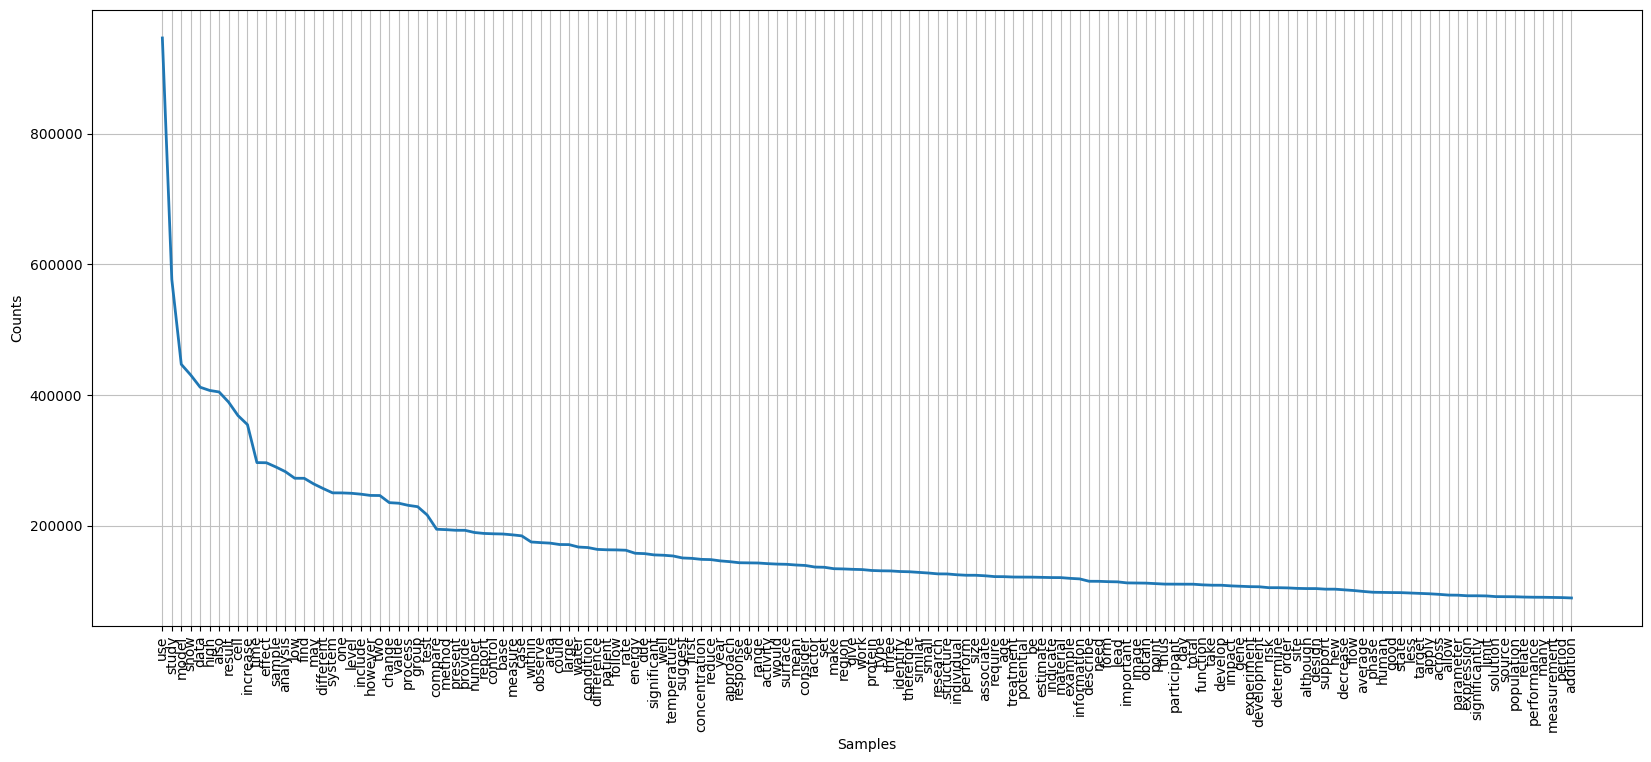

In [203]:
plt.figure(figsize=(20, 8))  # larghezza x altezza in pollici
freq_dist_body.plot(150)
plt.show()

<Axes: xlabel='Samples', ylabel='Counts'>

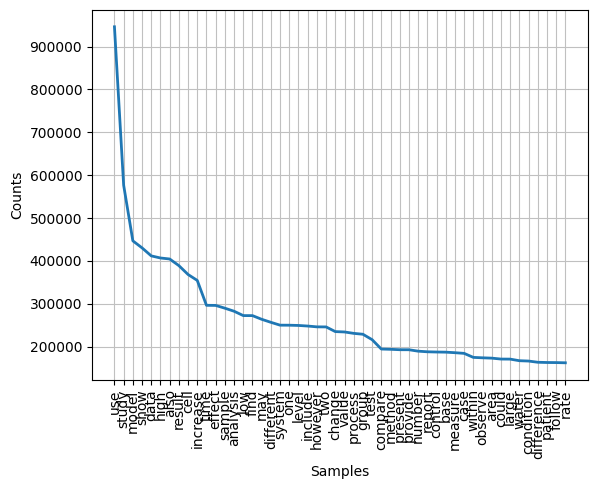

In [211]:
freq_dist_body.plot(50)

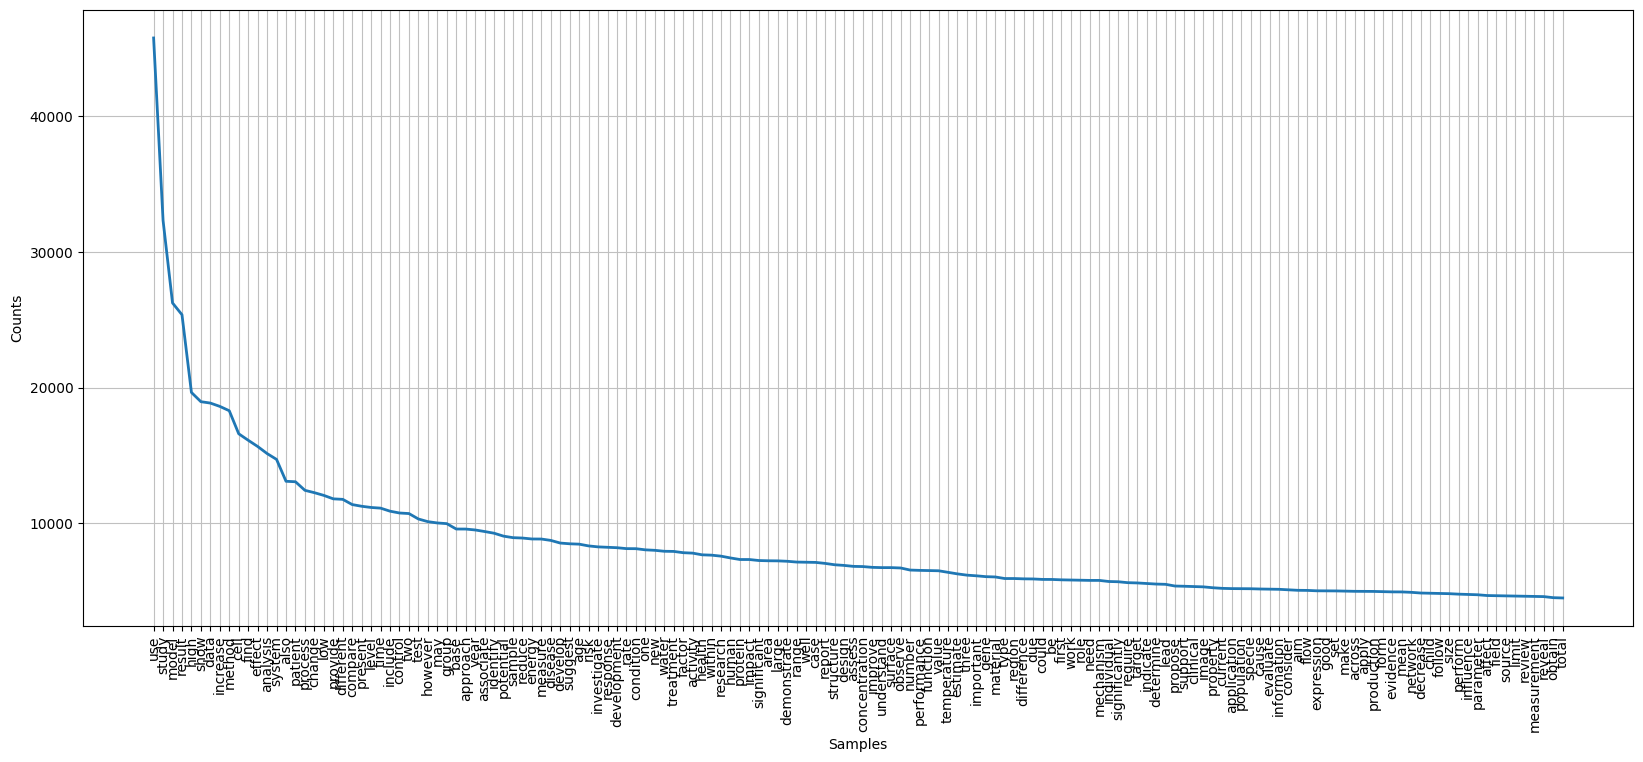

In [204]:
plt.figure(figsize=(20, 8))  # larghezza x altezza in pollici
freq_dist_abstract.plot(150)
plt.show()

<Axes: xlabel='Samples', ylabel='Counts'>

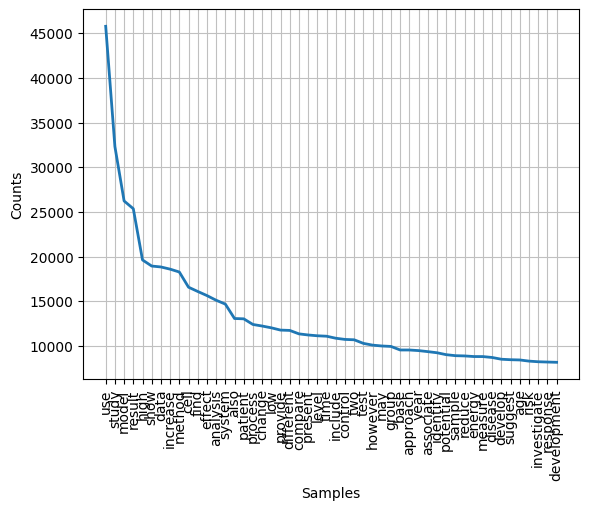

In [212]:
freq_dist_abstract.plot(50)

ISPEZIONE DEL TESTO CON nltk.Text

In [207]:
nltk_text = nltk.Text(all_body_tokens)

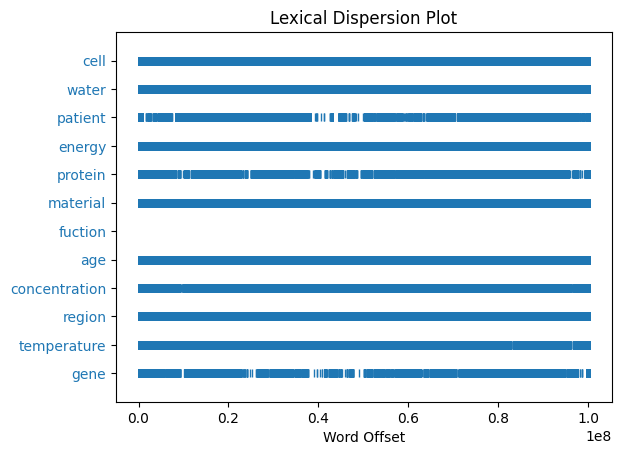

In [208]:
#how frequently a word appears in various parts of the text
nltk_text.dispersion_plot(['cell','water','patient', 'energy', 'protein', 'material', 'fuction', 'age', 'concentration', 'region', 'temperature', 'gene'])

In [209]:
nltk_text = nltk.Text(all_abstract_tokens)

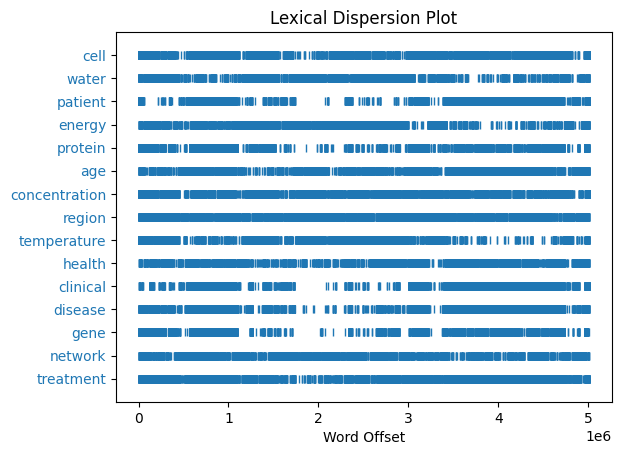

In [210]:
#how frequently a word appears in various parts of the text
nltk_text.dispersion_plot(['cell','water','patient', 'energy', 'protein', 'age', 'concentration', 'region', 'temperature', 'health', 'clinical', 'disease', 'gene', 'network', 'treatment'])